# Restaurant Data Analysis Project

# Import Libreries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re

# Step 1:- Load and Explore the Dataset

In [23]:
file_path = "Datasets.csv"   
df = pd.read_csv(file_path)

print(" Dataset Loaded Successfully!")
print("Rows & Columns:", df.shape)
df

 Dataset Loaded Successfully!
Rows & Columns: (9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,Naml۱ Gurme,208,��stanbul,"Kemanke�� Karamustafa Pa��a Mahallesi, R۱ht۱m ...",Karak�_y,"Karak�_y, ��stanbul",28.977392,41.022793,Turkish,...,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz A��ac۱,208,��stanbul,"Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...",Ko��uyolu,"Ko��uyolu, ��stanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.034640,41.055817,"Italian, World Cuisine",...,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,A���k Kahve,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.036019,41.057979,Restaurant Cafe,...,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901


In [3]:
df.info()   # Summary of columns & datatypes
df.shape    # (rows, columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

(9551, 21)

In [4]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


# Task 1: Top Cuisines
Determine the top three most
common cuisines in the dataset.

Calculate the percentage of
restaurants that serve each of the top
cuisines.

In [24]:
print("\n# Task 1: Top Cuisines #")

top_cuisines = df["Cuisines"].value_counts().head(3)
print("Top 3 Cuisines:\n", top_cuisines)

total_restaurants = len(df)
for cuisine, count in top_cuisines.items():
    print(f"{cuisine}: {count/total_restaurants*100:.2f}% of restaurants")


# Task 1: Top Cuisines #
Top 3 Cuisines:
 Cuisines
North Indian             936
North Indian, Chinese    511
Chinese                  354
Name: count, dtype: int64
North Indian: 9.80% of restaurants
North Indian, Chinese: 5.35% of restaurants
Chinese: 3.71% of restaurants


# Task 2: City Analysis

Identify the city with the highest number
of restaurants in the dataset.

Calculate the average rating for
restaurants in each city.

Determine the city with the highest
average rating.

In [7]:
print("\n# Task 2: City Analysis #")

# City with most restaurants
top_city = df["City"].value_counts().idxmax()
print("City with most restaurants:", top_city)

# Average rating per city
avg_rating_city = df.groupby("City")["Aggregate rating"].mean().sort_values(ascending=False)
print("Average Rating by City:\n", avg_rating_city.head())

best_city = avg_rating_city.idxmax()
print("City with highest average rating:", best_city)


# Task 2: City Analysis #
City with most restaurants: New Delhi
Average Rating by City:
 City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Name: Aggregate rating, dtype: float64
City with highest average rating: Inner City


# Task3 : Price Range Distribution

Create a histogram or bar chart to
visualize the distribution of price ranges
among the restaurants.

Calculate the percentage of restaurants
in each price range category.


# Task 3: Price Range Distribution #
Price range
1    46.53
2    32.59
3    14.74
4     6.14
Name: proportion, dtype: float64


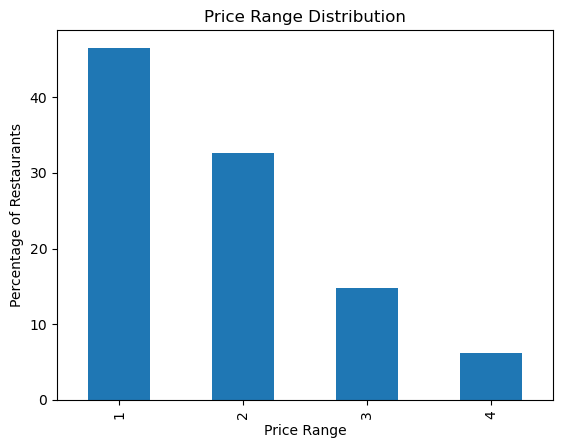

In [8]:
print("\n# Task 3: Price Range Distribution #")

price_counts = df["Price range"].value_counts(normalize=True) * 100
print(price_counts.round(2))

price_counts.plot(kind="bar", title="Price Range Distribution")
plt.xlabel("Price Range")
plt.ylabel("Percentage of Restaurants")
plt.show()

# Task4 : Online Delivery

Determine the percentage of restaurants
that offer online delivery.

Compare the average ratings of restaurants
with and without online delivery.

In [9]:
print("\n# Task 4: Online Delivery #")

delivery_counts = df["Has Online delivery"].value_counts(normalize=True) * 100
print(delivery_counts)

avg_rating_delivery = df.groupby("Has Online delivery")["Aggregate rating"].mean()
print("Average rating by delivery option:\n", avg_rating_delivery)


# Task 4: Online Delivery #
Has Online delivery
No     74.337766
Yes    25.662234
Name: proportion, dtype: float64
Average rating by delivery option:
 Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64


# Level 2

# Task 1: Restaurant Ratings

Analyze the distribution of aggregate
ratings and determine the most common
rating range.

Calculate the average number of votes
received by restaurants.


# Task 1: Restaurant Ratings #
Aggregate rating
0.0    2148
1.8       1
1.9       2
2.0       7
2.1      15
2.2      27
2.3      47
2.4      87
2.5     110
2.6     191
2.7     250
2.8     315
2.9     381
3.0     468
3.1     519
3.2     522
3.3     483
3.4     498
3.5     480
3.6     458
3.7     427
3.8     400
3.9     335
4.0     266
4.1     274
4.2     221
4.3     174
4.4     144
4.5      95
4.6      78
4.7      42
4.8      25
4.9      61
Name: count, dtype: int64


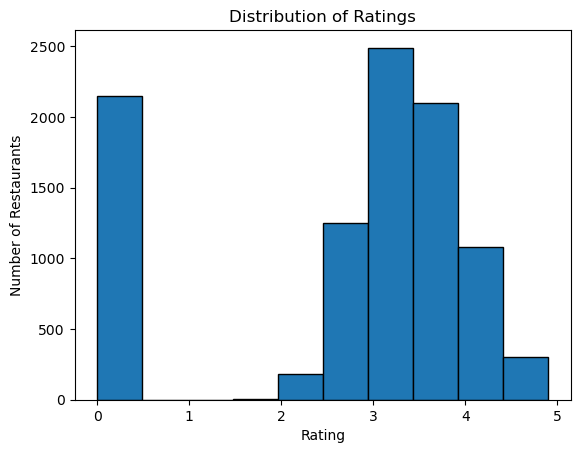

Average votes: 156.91


In [17]:
print("\n# Task 1: Restaurant Ratings #")

rating_dist = df["Aggregate rating"].value_counts().sort_index()
print(rating_dist)

plt.hist(df["Aggregate rating"], bins=10, edgecolor="black")
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")
plt.show()

print("Average votes:", df["Votes"].mean().round(2))

# Task 2: Cuisine Combination

Identify the most common combinations of
cuisines in the dataset.

Determine if certain cuisine combinations
tend to have higher ratings.

In [16]:
print("\n# Task 2: Cuisine Combination #")

# Count most common cuisine combos
combo_counts = df["Cuisines"].value_counts().head(10)
print(combo_counts)

# Average rating for popular combos
combo_rating = df.groupby("Cuisines")["Aggregate rating"].mean().sort_values(ascending=False).head(10)
print("Top Cuisine Combos by Rating:\n", combo_rating)


# Task 2: Cuisine Combination #
Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64
Top Cuisine Combos by Rating:
 Cuisines
Italian, Deli               4.9
Hawaiian, Seafood           4.9
American, Sandwich, Tea     4.9
Continental, Indian         4.9
European, Asian, Indian     4.9
European, Contemporary      4.9
European, German            4.9
BBQ, Breakfast, Southern    4.9
American, Coffee and Tea    4.9
Sunda, Indonesian           4.9
Name: Aggregate rating, dtype: float64


# Task 3: Geographic Analysis

Plot the locations of restaurants on a
map using longitude and latitude
coordinates.

Identify any patterns or clusters of
restaurants in specific areas.


### Task 3: Geographic Analysis ###


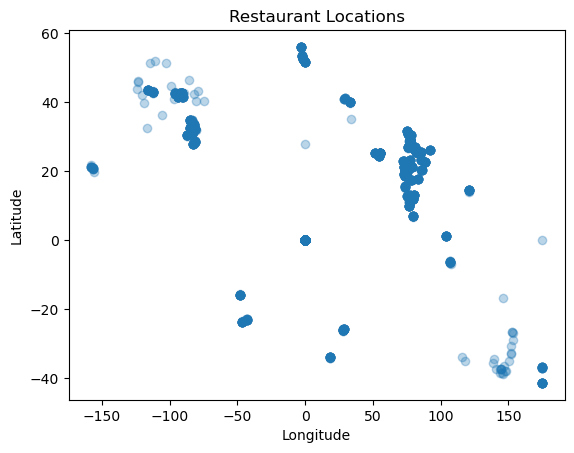

In [15]:
if "Latitude" in df.columns and "Longitude" in df.columns:
    print("\n### Task 3: Geographic Analysis ###")
    plt.scatter(df["Longitude"], df["Latitude"], alpha=0.3)
    plt.title("Restaurant Locations")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()
else:
    print("\nNo Latitude/Longitude data available.")

# Task 4: Restaurant Chains

Identify if there are any restaurant chains
present in the dataset.

Analyze the ratings and popularity of
different restaurant chains.

In [14]:
print("\n# Task 4: Restaurant Chains #")

chain_counts = df["Restaurant Name"].value_counts()
chains = chain_counts[chain_counts > 1]
print("Top Chains:\n", chains.head(10))

# Ratings of top chains
chain_ratings = df[df["Restaurant Name"].isin(chains.index)].groupby("Restaurant Name")["Aggregate rating"].mean().sort_values(ascending=False).head(10)
print("Top Chains by Rating:\n", chain_ratings)


# Task 4: Restaurant Chains #
Top Chains:
 Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64
Top Chains by Rating:
 Restaurant Name
Talaga Sampireun             4.900
Silantro Fil-Mex             4.850
AB's Absolute Barbecues      4.850
AB's - Absolute Barbecues    4.825
Naturals Ice Cream           4.800
Gymkhana                     4.700
The Cheesecake Factory       4.650
Dishoom                      4.600
Garota de Ipanema            4.600
Chili's                      4.580
Name: Aggregate rating, dtype: float64


# Level 3

# Task 1: Restaurant Reviews

Analyze the text reviews to identify the most
common positive and negative keywords.

Calculate the average length of reviews and
explore if there is a relationship between
review length and rating.


Top Positive Keywords: [('good', 3179), ('excellent', 301)]
Top Negative Keywords: [('poor', 186)]

Average review length (words): 1.34


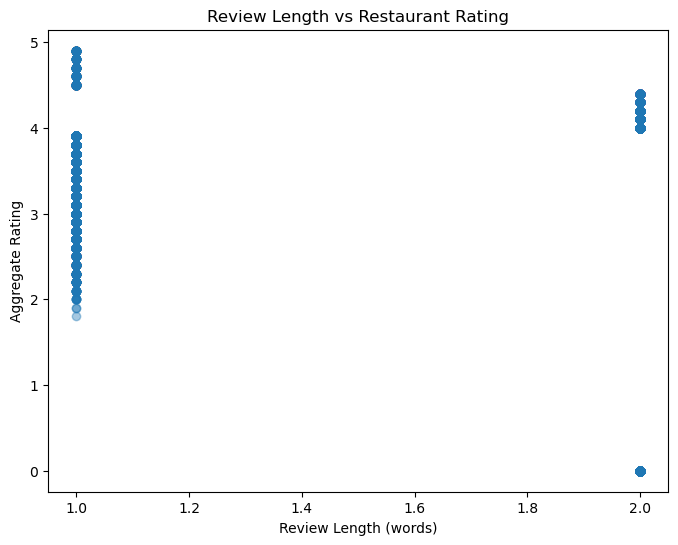

In [22]:
# 1. Keyword Analysis (Positive/Negative)

positive_words = ["good","great","excellent","amazing","tasty","delicious","friendly","fast","love","perfect"]
negative_words = ["bad","poor","terrible","slow","rude","worst","disappointing","awful","horrible","dirty"]

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df_reviews["cleaned"] = df_reviews["Rating text"].apply(clean_text)

positive_counts = Counter()
negative_counts = Counter()

for review in df_reviews["cleaned"]:
    words = review.split()
    for word in words:
        if word in positive_words:
            positive_counts[word] += 1
        elif word in negative_words:
            negative_counts[word] += 1

print("\nTop Positive Keywords:", positive_counts.most_common(10))
print("Top Negative Keywords:", negative_counts.most_common(10))


# 2. Average Review Length

df_reviews["review_length"] = df_reviews["cleaned"].apply(lambda x: len(x.split()))
avg_length = df_reviews["review_length"].mean().round(2)
print("\nAverage review length (words):", avg_length)


# 3. Relationship: Review Length vs Rating

if "Aggregate rating" in df_reviews.columns:
    plt.figure(figsize=(8,6))
    plt.scatter(df_reviews["review_length"], df_reviews["Aggregate rating"], alpha=0.4)
    plt.title("Review Length vs Restaurant Rating")
    plt.xlabel("Review Length (words)")
    plt.ylabel("Aggregate Rating")
    plt.show()
else:
    print("\nNo 'Aggregate rating' column found for correlation analysis.")

# Task 2: Votes Analysis

Identify the restaurants with the highest and
lowest number of votes.

Analyze if there is a correlation between the
number of votes and the rating of a
restaurant.

In [20]:
print("\n# Task 2: Votes Analysis #")

max_votes = df.loc[df["Votes"].idxmax()]
min_votes = df.loc[df["Votes"].idxmin()]

print("Restaurant with MOST votes:\n", max_votes[["Restaurant Name","City","Votes","Aggregate rating"]])
print("Restaurant with LEAST votes:\n", min_votes[["Restaurant Name","City","Votes","Aggregate rating"]])

correlation = df["Votes"].corr(df["Aggregate rating"])
print("Correlation between votes and ratings:", correlation)


# Task 2: Votes Analysis #
Restaurant with MOST votes:
 Restaurant Name          Toit
City                Bangalore
Votes                   10934
Aggregate rating          4.8
Name: 728, dtype: object
Restaurant with LEAST votes:
 Restaurant Name     Cantinho da Gula
City                      S��o Paulo
Votes                              0
Aggregate rating                 0.0
Name: 69, dtype: object
Correlation between votes and ratings: 0.3136905841954117


# Task 3: Price Range vs. Online Delivery And Table Booking 

Analyze if there is a relationship between the
price range and the availability of online
delivery and table booking.

Determine if higher-priced restaurants are
more likely to offer these services.


# Task 3: Price Range vs Services #
             Has Online delivery  Has Table booking
Price range                                        
1                      15.774077           0.022502
2                      41.310633           7.677482
3                      29.190341          45.738636
4                       9.044369          46.757679


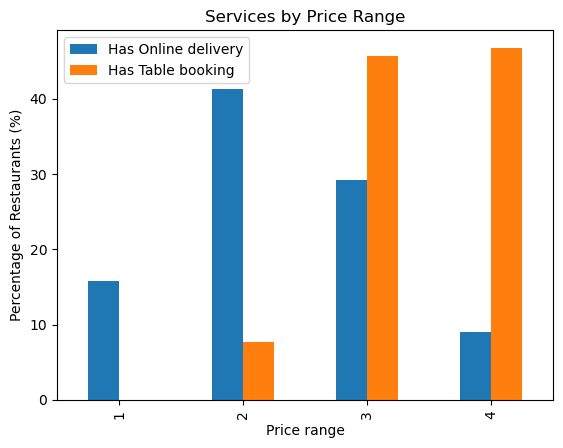

In [21]:
print("\n# Task 3: Price Range vs Services #")

df_services = df[["Price range","Has Online delivery","Has Table booking"]].dropna()
df_services["Has Online delivery"] = df_services["Has Online delivery"].map({"Yes":1,"No":0})
df_services["Has Table booking"] = df_services["Has Table booking"].map({"Yes":1,"No":0})

service_percent = df_services.groupby("Price range").mean() * 100
print(service_percent)

service_percent.plot(kind="bar")
plt.title("Services by Price Range")
plt.ylabel("Percentage of Restaurants (%)")
plt.show()